In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [46]:
RANDOM_STATE=42
MAX_ROWS=100000 

In [47]:
df=pd.read_csv("02-14-2018.csv")
df.columns=df.columns.str.strip()
print("Loaded:", df.shape)
print(df["Label"].value_counts())

Loaded: (1048575, 80)
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


In [48]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(df.shape)

(1044751, 80)


In [49]:
df.drop(columns=["Timestamp", "Dst Port", "Protocol"], inplace=True)
print("After dropping columns:", df.shape)

After dropping columns: (1044751, 77)


In [50]:
if len(df) > MAX_ROWS:
    df, _ = train_test_split(df, train_size=MAX_ROWS, stratify=df["Label"], random_state=RANDOM_STATE)
    df = df.reset_index(drop=True)
print("After subsampling:", df.shape)
print(df["Label"].value_counts())

After subsampling: (100000, 77)
Label
Benign            63538
FTP-BruteForce    18507
SSH-Bruteforce    17955
Name: count, dtype: int64


In [51]:
df["binary_label"]=(df["Label"] != "Benign").astype(int)
print("\nClass balance (%):")
print(df["binary_label"].value_counts(normalize=True) * 100)



Class balance (%):
binary_label
0    63.538
1    36.462
Name: proportion, dtype: float64


In [52]:
X=df.drop(columns=["Label", "binary_label"]).select_dtypes(include=np.number)
y=df["binary_label"]
print("Feature matrix:", X.shape)

Feature matrix: (100000, 76)


In [53]:
X=X.clip(lower=X.quantile(0.001), upper=X.quantile(0.999), axis=1)

In [54]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

In [55]:
zero_var_cols=X.columns[X.std() == 0]
X=X.drop(columns=zero_var_cols)

In [56]:
scaler=StandardScaler()
X_train_s=scaler.fit_transform(X_train)
X_test_s=scaler.transform(X_test)

In [57]:
svm_linear=SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_linear.fit(X_train_s, y_train)
pred_linear=svm_linear.predict(X_test_s)
print(classification_report(y_test, pred_linear, target_names=["normal", "attack"]))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     15885
      attack       1.00      1.00      1.00      9115

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000



In [58]:
svm_rbf=SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE)
svm_rbf.fit(X_train_s, y_train)
pred_rbf = svm_rbf.predict(X_test_s)
print(classification_report(y_test, pred_rbf, target_names=["normal", "attack"]))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     15885
      attack       1.00      1.00      1.00      9115

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000



In [59]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(svm_rbf, X_train_s, y_train, cv=5, scoring="recall")
print("Recall across 5 folds:", scores)

Recall across 5 folds: [0.99981718 1.         0.99981715 1.         1.        ]


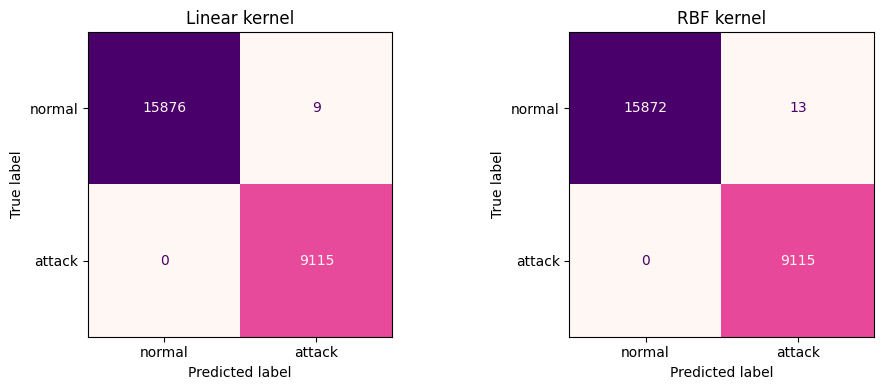

In [60]:
fig, axes=plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_linear, display_labels=["normal", "attack"],
    ax=axes[0], colorbar=False, cmap="RdPu")
axes[0].set_title("Linear kernel")
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rbf, display_labels=["normal", "attack"],
    ax=axes[1], colorbar=False, cmap="RdPu")
axes[1].set_title("RBF kernel")
plt.tight_layout()
plt.show()

/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/mshvrnina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in 

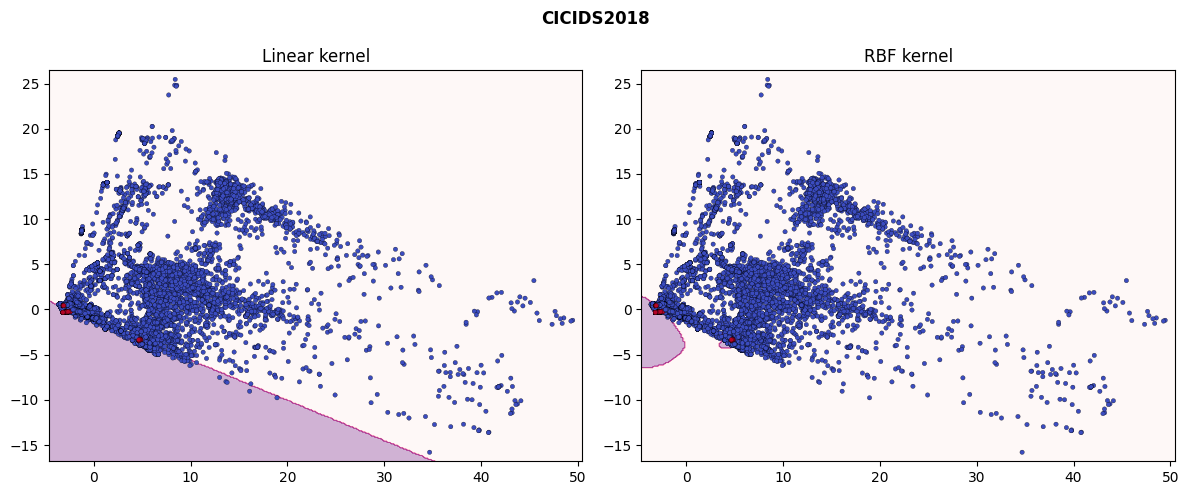

In [61]:
pca=PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_s)
svm_linear_2d=SVC(kernel="linear", class_weight="balanced").fit(X_train_2d, y_train)
svm_rbf_2d=SVC(kernel="rbf", gamma="scale", class_weight="balanced").fit(X_train_2d, y_train)
def plot_boundary(ax, model, X, y, title):
    x_min, x_max=X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max=X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy=np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z=model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdPu")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10, edgecolor="k", linewidth=0.2)
    ax.set_title(title)

fig, axes=plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(axes[0], svm_linear_2d, X_train_2d, y_train.values, "Linear kernel")
plot_boundary(axes[1], svm_rbf_2d, X_train_2d, y_train.values, "RBF kernel")
plt.suptitle("CICIDS2018", fontweight="bold")
plt.tight_layout()
plt.savefig("decision_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()